# Used Car Price Prediction

## Project Overview
This project predicts the price of used cars in India using the **Scikit-learn** library.

The dataset contains information about pre-owned cars, including:
- Brand and model
- Transmission type
- Manufacturing year
- Fuel type
- Engine capacity
- Kilometers driven
- Ownership history

## Goal
Build a regression model that can predict a car's price based on its features.

## Workflow
1. Load and inspect the data
2. Preprocess features (encoding + scaling)
3. Train multiple models and compare them
4. Tune the best model with GridSearchCV
5. Evaluate the final model on the test set
6. Analyze feature importance
7. Save the model for future use

## Tools Used
- Python, NumPy, Pandas
- Scikit-learn (models, preprocessing, model selection, metrics)
- Matplotlib (visualization)
- Joblib (model persistence)

## 1. Import Libraries

We import all required libraries at the beginning of the notebook for clarity.

In [1]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

## 2. Load the Dataset

The dataset has already been cleaned and stored as `cars.csv`.
Each row represents one used car listing.

In [2]:
df = pd.read_csv('../data/cleaned/cars.csv')
df.head()

,Unnamed: 0,brand,model,transmission,make_year,fuel_type,engine_capacity(CC),km_driven,ownership,price,overall_cost,has_insurance,spare_key,reg_number,title
0,0,Mahindra,Thar LX D 4WD MT CONVERTIBLE,Manual,2020,Diesel,2184.0,11003,1st owner,1231000,23431,True,False,HR26,2020 Mahindra Thar LX D 4WD MT CONVERTIBLE
1,1,Hyundai,Verna 1.6 VTVT SX,Manual,2018,Petrol,1591.0,66936,1st owner,786000,15359,True,False,DL7C,2018 Hyundai Verna 1.6 VTVT SX
2,2,Tata,Harrier XT PLUS 2.0L KRYOTEC DARK EDITON,Manual,2022,Diesel,1956.0,27990,1st owner,1489000,28349,True,False,HR29,2022 Tata Harrier XT PLUS 2.0L KRYOTEC DARK ED...
3,3,Honda,City 1.5L I-VTE V CVT,Automatic,2023,Petrol,1498.0,5061,1st owner,1227000,23355,True,True,DL4C,2023 Honda City 1.5L I-VTE V CVT
4,4,Ford,Ecosport TITANIUM 1.5L DIESEL,Manual,2021,Diesel,1498.0,23480,1st owner,887000,16883,True,False,UP14,2021 Ford Ecosport TITANIUM 1.5L DIESEL


## 3. Feature Preparation

Steps:
1. Select relevant columns from the dataframe.
2. Apply One-Hot Encoding to categorical columns (`brand`, `transmission`, `ownership`).
3. Split the data into training (80%) and testing (20%) sets.
4. Standardize numerical features using `StandardScaler`.

**Note:** The scaler is fitted on the training set only, then applied to the test set.
This avoids data leakage.

In [3]:
X = pd.get_dummies(df[['brand', 'transmission', 'make_year',
        'engine_capacity(CC)', 'ownership', 'km_driven']], columns=['brand', 'transmission', 'ownership'], drop_first=False, dtype=int)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Model Training & Evaluation

We train several regression models and compare their performance on the test set.

Metrics used:
- **MSE** (Mean Squared Error): average squared difference between prediction and truth.
- **MAE** (Mean Absolute Error): average absolute difference (in price units).
- **RMSE** (Root Mean Squared Error): square root of MSE (same unit as price).
- **R²** (Coefficient of Determination): how much variance the model explains (closer to 1 is better).

In [4]:
model = LinearRegression() 
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [5]:
print('MSE:', mean_squared_error(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2:', r2_score(y_test, y_pred))

MSE: 21213406229.30634
MAE: 106036.58957414674
RMSE: 145648.22769023431
R2: 0.7939933032948379


In [7]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)

In [8]:
print('MSE:', mean_squared_error(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2:', r2_score(y_test, y_pred))

MSE: 25896340648.38548
MAE: 117022.90825012699
RMSE: 160923.39994042346
R2: 0.7848176057479757


In [9]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)

In [10]:
print('MSE:', mean_squared_error(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2:', r2_score(y_test, y_pred))

MSE: 25898867165.596104
MAE: 117021.05784250486
RMSE: 160931.2498105825
R2: 0.7847966119701334


In [11]:
from sklearn.tree import DecisionTreeRegressor
decision_tree = DecisionTreeRegressor()
decision_tree.fit(X_train_scaled, y_train)
y_pred = decision_tree.predict(X_test_scaled)

In [12]:
print('MSE:', mean_squared_error(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2:', r2_score(y_test, y_pred))

MSE: 22398527629.233513
MAE: 102827.0944741533
RMSE: 149661.37654462995
R2: 0.8138822442745757


In [28]:
from sklearn.ensemble import RandomForestRegressor
random_forest = RandomForestRegressor()
random_forest.fit(X_train_scaled, y_train)
y_pred = random_forest.predict(X_test_scaled)

In [31]:
print('MSE:', mean_squared_error(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2:', r2_score(y_test, y_pred))

MSE: 13171189417.468805
MAE: 82660.39215686274
RMSE: 114765.80247385893
R2: 0.8905556536933119


In [20]:
from sklearn.neighbors import KNeighborsRegressor
neighbors = KNeighborsRegressor()
neighbors.fit(X_train_scaled, y_train)
y_pred = neighbors.predict(X_test_scaled)

In [21]:
print('MSE:', mean_squared_error(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2:', r2_score(y_test, y_pred))

MSE: 23788064099.821747
MAE: 105859.89304812835
RMSE: 154233.79687935373
R2: 0.8023360652718553


In [4]:
from sklearn.ensemble import GradientBoostingRegressor
gradient_boosting = GradientBoostingRegressor()
gradient_boosting.fit(X_train_scaled, y_train)
y_pred = gradient_boosting.predict(X_test_scaled)

In [5]:
print('MSE:', mean_squared_error(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2:', r2_score(y_test, y_pred))

MSE: 17136445130.352829
MAE: 95258.8239712459
RMSE: 130906.24557427666
R2: 0.8618994773858482


## 5. Hyperparameter Tuning

We use `GridSearchCV` to find the best hyperparameters for `GradientBoostingRegressor`.

Grid search tries all combinations of parameters and evaluates them with 5-fold cross-validation.
The best combination is selected based on the highest R² score.

In [24]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=gradient_boosting,
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

print('Best params:', grid.best_params_)
print('Best score:', grid.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best params: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500, 'subsample': 0.8}
Best score: 0.883258384242709


In [25]:
gradient_boosting_with_params = GradientBoostingRegressor(learning_rate=0.05,
                                                          max_depth=4,
                                                          min_samples_leaf=1,
                                                          min_samples_split=2,
                                                          n_estimators=500,
                                                          subsample=0.8)
gradient_boosting_with_params.fit(X_train_scaled, y_train)
y_pred = gradient_boosting_with_params.predict(X_test_scaled)

In [ ]:
print('MSE:', mean_squared_error(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2:', r2_score(y_test, y_pred)) 

## 6. Save the Final Model

We save the tuned Gradient Boosting model using `joblib`.

The saved file (`best_model.pkl`) can be loaded later for predictions
without retraining.

In [ ]:
joblib.dump(gradient_boosting_with_params, '../models/best_model.pkl')

In [6]:
model = joblib.load('../models/best_model.pkl')
y_pred = model.predict(X_test_scaled)

## 7. Visual Evaluation

Two plots are used to evaluate the final model:

1. **Predicted vs True values**
   - Points close to the diagonal line mean good predictions.

2. **Residual plot (True − Predicted)**
   - Should be randomly scattered around 0.
   - Any pattern suggests the model is missing something.

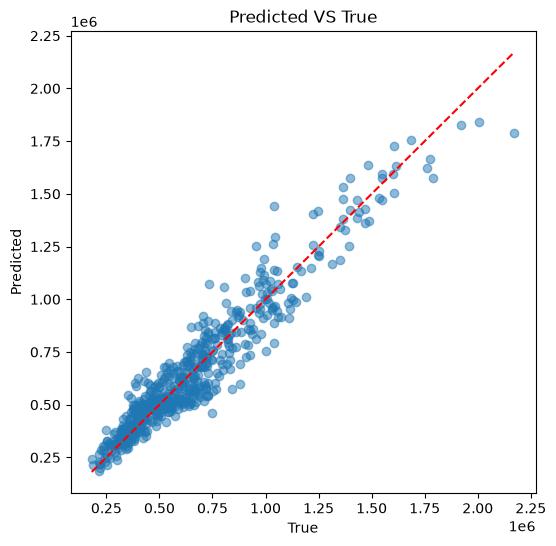

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Predicted VS True')
plt.show()

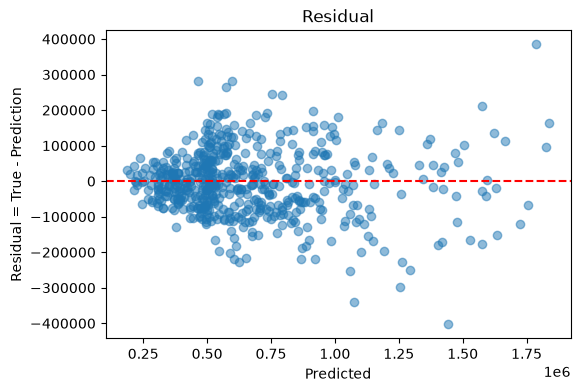

In [18]:
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')

plt.xlabel('Predicted')
plt.ylabel('Residual = True - Prediction')
plt.title('Residual')
plt.show()

## 8. Feature Importance

Tree-based models like Gradient Boosting can tell us which features contribute the most to predictions.

This helps us understand:
- What drives the price of a used car
- Whether the model makes sense from a business perspective

Text(0.5, 1.0, 'Features importance')

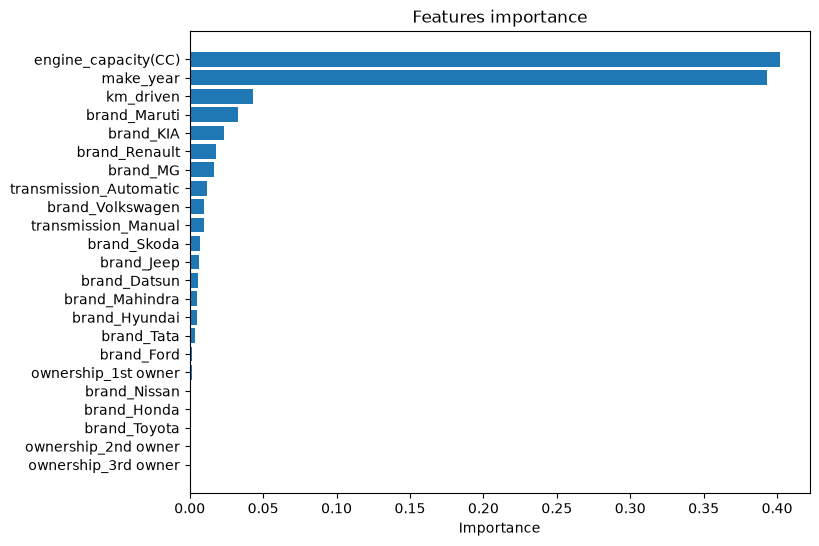

In [20]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_imp.index, feat_imp.values)
plt.xlabel('Importance')
plt.title('Features importance')